In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Choix des datasets

Nous allons prendre les datasets **CIFAR-10** et **Hymenotera** car ils sont facilement téléchargeables et semblent adaptés au projet. On utilise pytorch pour ce notebook.

## Description des datasets utilisés

| Dataset | Description | Taille des images | Nombre de classes | Exemples de classes | Nombre d'images
| :--- | :--- | :--- | :--- | :--- | :--- |
| **CIFAR-10** | Dataset d'images couleur d'objets divers, plus complexe et varié que MNIST. | 32x32 pixels | 10 | Avion, Voiture, Oiseau, Chat, Cerf, Chien, Grenouille, Cheval, Bateau, Camion | ? |
| **Hymenoptera** | Fourmis vs Abeilles. | 224x224 pixels | 2 | Fourmis, Abeilles | ? |


- CIFAR-10 : disponible directement avec torch
- Hymenoptera : à télécharger ici -> https://www.kaggle.com/datasets/thedatasith/hymenoptera

Ils sont trop gros pour être mis sur le git, donc il faut les télécharger sur votre ordinateur en local. Le dossier gitignore gère cela.


In [2]:
import prepa_dataset

### Préparation de Hymenoptera

In [3]:
import kagglehub
import os
from torchvision import transforms

/home/davodeau/.conda/envs/HDDLtorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
path_hymenoptera = kagglehub.dataset_download("thedatasith/hymenoptera")+"/hymenoptera"

print("Path to hymenoptera dataset files:", path_hymenoptera)

train_path_hymenoptera = os.path.join(path_hymenoptera, 'train')
test_path_hymenoptera = os.path.join(path_hymenoptera, 'val')

Path to hymenoptera dataset files: /home/davodeau/.cache/kagglehub/datasets/thedatasith/hymenoptera/versions/5/hymenoptera


In [5]:
# Transformation pour Hymenoptera (obligatoire : resize car tailles variées)
hym_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

x_train_hymenoptera, y_train_hymenoptera, class_names = prepa_dataset.load_folder_to_tensors(train_path_hymenoptera, hym_transforms)
x_test_hymenoptera, y_test_hymenoptera, class_names = prepa_dataset.load_folder_to_tensors(test_path_hymenoptera, hym_transforms)

### Préparation de CIFAR-10

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import random_split
import torch

# Resize pour être cohérent avec les modèles pré-entraînés (ex: 224x224)
cifar_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    transform=cifar_transforms,
    download=True
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    transform=cifar_transforms,
    download=True
)

val_ratio = 0.1
n_total = len(full_train_dataset)
n_val = int(val_ratio * n_total)
n_train = n_total - n_val
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [n_train, n_val]
)


# --- Conversion en tensors X et y ---
# --- Train ---
x_train_cifar10 = torch.stack([data[0] for data in train_dataset])
y_train_cifar10 = torch.tensor([data[1] for data in train_dataset])

# --- Validation ---
x_val_cifar10 = torch.stack([data[0] for data in val_dataset])
y_val_cifar10 = torch.tensor([data[1] for data in val_dataset])

# --- Test ---
x_test_cifar10 = torch.stack([data[0] for data in test_dataset])
y_test_cifar10 = torch.tensor([data[1] for data in test_dataset])

print(x_train_cifar10.shape)
print(x_val_cifar10.shape)
print(x_test_cifar10.shape)

class_names_cifar = full_train_dataset.classes


torch.Size([45000, 3, 32, 32])
torch.Size([5000, 3, 32, 32])
torch.Size([10000, 3, 32, 32])


# Visualisation des datasets

### hymenoptera

----- Dataset Description -----
Train data: 244 images
Dimensions détectées : 224x224 pixels, 3 canaux
Format PyTorch (Channels First) : Oui
Number of classes: 2
--------------------------------


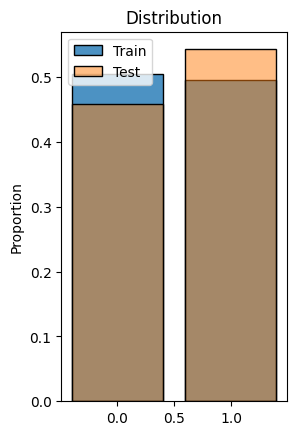

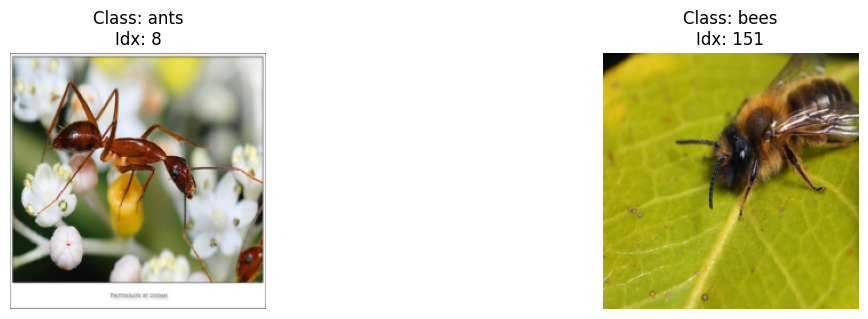

In [7]:
prepa_dataset.describe_image_dataset(
    x_train_hymenoptera, y_train_hymenoptera,
    x_test_hymenoptera, y_test_hymenoptera,
    class_names=class_names,
    cmap=None
)

### CIFAR-10

----- Dataset Description -----
Train data: 45000 images
Dimensions détectées : 32x32 pixels, 3 canaux
Format PyTorch (Channels First) : Oui
Number of classes: 10
--------------------------------


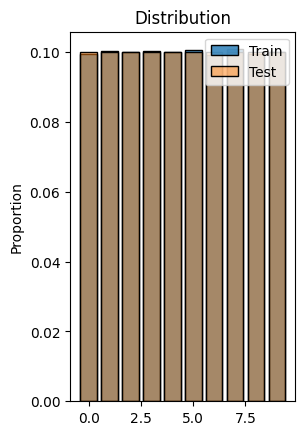

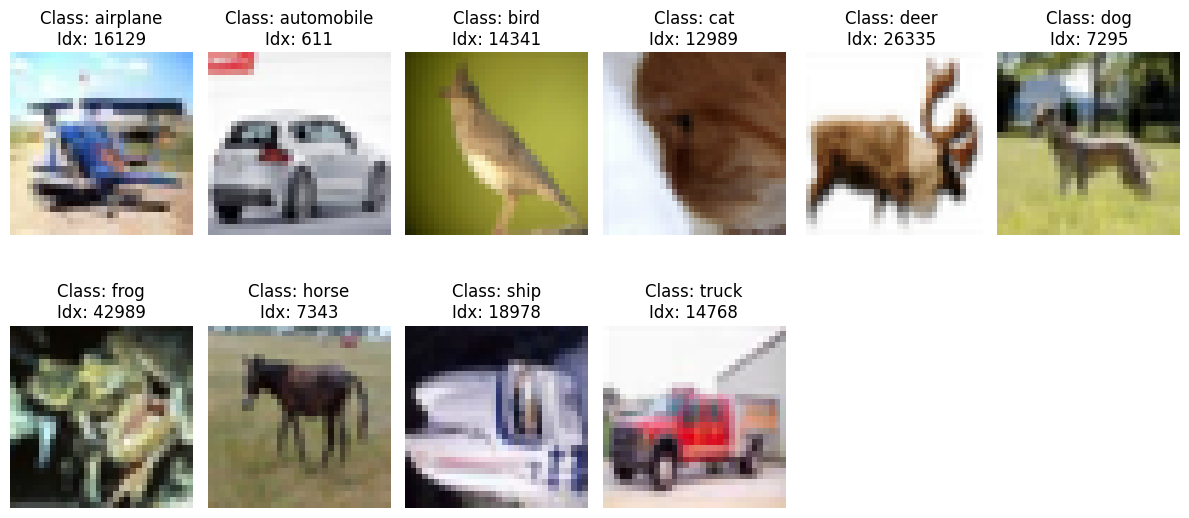

In [8]:
prepa_dataset.describe_image_dataset(
    x_train_cifar10, y_train_cifar10,
    x_test_cifar10, y_test_cifar10,
    class_names=class_names_cifar,
    cmap=None
)

# Convolutional Neural Network (CNN or ConvNet)

On va commencer par la classification par CNN

### Data format

L'architecture de convolution prend en entrée des **images** et non des vecteurs 1D. Un certain formatage des données reste nécessaire.

Une **troisième dimension** est requise : la dimension des **canaux** (ou *channels*), qui permet de décrire chaque pixel.
- Pour les images en couleur, chaque pixel est codé par **plusieurs valeurs** (canaux **RGB** : Rouge, Vert, Bleu).

Ainsi, il est nécessaire de **redimensionner** les images :
- Pour CIFAR-10 : passer d'une dimension **$32 \times 32$** à **$32 \times 32 \times 3$** (pour inclure les 3 canaux RGB)
- Pour Hymenoptera : passer d'une dimension **$224 \times 224$** à **$224 \times 224 \times 3$** (pour inclure les 3 canaux RGB)

## Achitecture pour des images de couleurs



### Architecture du Modèle : Custom ResNet

Pour améliorer les performances et la stabilité de l'apprentissage par rapport à un CNN séquentiel classique (type VGG), nous implémentons une architecture basée sur **ResNet (Residual Network)**.

#### 1. Le Bloc Résiduel (`ResidualBlock`)
L'innovation principale de cette architecture est l'introduction de **connexions résiduelles** (skip connections). Au lieu d'empiler simplement des couches de convolution, chaque bloc ajoute l'entrée originale $x$ à la sortie des convolutions $F(x)$ :

$$\text{Output} = \text{ReLU}(F(x) + x)$$

Cette technique permet :
* De combattre le problème de **disparition du gradient** (vanishing gradient) dans les réseaux profonds.
* D'apprendre plus facilement l'identité si une couche n'est pas nécessaire.

#### 2. Structure du `ResNetCustom`
Le réseau est structuré en 4 étapes principales augmentant progressivement la complexité sémantique (profondeur) tout en réduisant la dimension spatiale :

* **Initialisation :** Convolution $3 \times 3$ (64 filtres).
* **Layer 1 :** 64 filtres (taille spatiale inchangée).
* **Layer 2 :** 128 filtres (downsampling / 2).
* **Layer 3 :** 256 filtres (downsampling / 2).
* **Layer 4 :** 512 filtres (downsampling / 2).

#### 3. Adaptabilité Universelle (`AdaptiveAvgPool2d`)
Une spécificité importante de cette implémentation est l'utilisation de l'**Adaptive Average Pooling** en fin de réseau.
* Contrairement à un `Flatten` classique qui dépend de la taille d'entrée, cette couche force la sortie spatiale à **$1 \times 1$**, quelle que soit la taille de l'image en entrée.
* **Conséquence :** Ce même modèle peut être entraîné indifféremment sur **CIFAR-10** ($32 \times 32$ px) ou **Hymenoptera** ($224 \times 224$ px) sans modifier la couche linéaire finale (`fc`).

expliquer rapidement la cellule du dessous

In [9]:
from torch.utils.data import TensorDataset, DataLoader

def get_dataloaders(x, y, batch_size=64, shuffle=True):
    """
    Enveloppe les tenseurs dans un DataLoader PyTorch.
    Gère la conversion des labels en LongTensor (requis par CrossEntropy).
    """
    # CrossEntropyLoss attend des labels de type Long (int64)
    if not isinstance(y, torch.LongTensor):
        y = y.long()
        
    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader

# --- Configuration pour CIFAR-10 ---
# Batch size standard : 64 ou 128
train_loader_cifar = get_dataloaders(x_train_cifar10, y_train_cifar10, batch_size=64, shuffle=True)
val_loader_cifar   = get_dataloaders(x_test_cifar10, y_test_cifar10, batch_size=64, shuffle=False)

# --- Configuration pour Hymenoptera ---
# Batch size plus petit car images 224x224 (plus lourd en VRAM)
# et dataset plus petit (~244 images)
train_loader_hym = get_dataloaders(x_train_hymenoptera, y_train_hymenoptera, batch_size=32, shuffle=True)
val_loader_hym   = get_dataloaders(x_test_hymenoptera, y_test_hymenoptera, batch_size=32, shuffle=False)

On entraine le modèle pour CIFAR-10

In [10]:
import train
import Custom_ResNet
import torch.nn as nn

# Pour CIFAR-10
criterion = nn.CrossEntropyLoss()
model_resnet_cifar = Custom_ResNet.ResNetCustom(num_classes=10).to(device)
optimizer_resnet = torch.optim.Adam(model_resnet_cifar.parameters(), lr=0.001)

print("\n=== ENTRAÎNEMENT CIFAR-10 (CNN Standard) ===")

# On réinitialise l'optimizer pour être sûr (si tu relances la cellule)
optimizer_cifar = torch.optim.Adam(model_resnet_cifar.parameters(), lr=0.001)
num_epochs_cifar = 10  # 10 à 15 époques suffisent généralement pour voir la convergence
history_cifar = train.train_model(
    model=model_resnet_cifar, # Ton modèle ResNetCustom pour CIFAR-10
    train_loader=train_loader_cifar,
    val_loader=val_loader_cifar,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optimizer_cifar,
    num_epochs=num_epochs_cifar, # 10 à 15 époques suffisent généralement pour voir la convergence
    device=device
)


=== ENTRAÎNEMENT CIFAR-10 (CNN Standard) ===
Démarrage de l'entraînement sur cuda pour 10 epochs
Epoch [1/10] Train Loss: 1.3796 Acc: 0.4961 | Val Loss: 1.1064 Acc: 0.6053
Epoch [2/10] Train Loss: 0.8858 Acc: 0.6823 | Val Loss: 0.8941 Acc: 0.6912
Epoch [3/10] Train Loss: 0.6668 Acc: 0.7669 | Val Loss: 0.6165 Acc: 0.7870
Epoch [4/10] Train Loss: 0.5164 Acc: 0.8205 | Val Loss: 0.6558 Acc: 0.7790
Epoch [5/10] Train Loss: 0.4016 Acc: 0.8596 | Val Loss: 0.5791 Acc: 0.8090
Epoch [6/10] Train Loss: 0.3094 Acc: 0.8908 | Val Loss: 0.5744 Acc: 0.8157
Epoch [7/10] Train Loss: 0.2262 Acc: 0.9206 | Val Loss: 0.6014 Acc: 0.8204
Epoch [8/10] Train Loss: 0.1642 Acc: 0.9415 | Val Loss: 0.6023 Acc: 0.8308
Epoch [9/10] Train Loss: 0.1176 Acc: 0.9588 | Val Loss: 0.7102 Acc: 0.8149
Epoch [10/10] Train Loss: 0.0984 Acc: 0.9663 | Val Loss: 0.7078 Acc: 0.8209
Entraînement terminé en 4m 21s


On entraine de la même manière pour HYMENOPTERA

In [11]:
# Pour Hymenoptera
model_resnet_hym = Custom_ResNet.ResNetCustom(num_classes=2).to(device)
optimizer_resnet_hym = torch.optim.Adam(model_resnet_hym.parameters(), lr=0.001)

print("\n=== ENTRAÎNEMENT HYMENOPTERA (CNN Adapté) ===")

# Optimizer spécifique pour ce modèle
optimizer_hym = torch.optim.Adam(model_resnet_hym.parameters(), lr=0.001)
num_epochs_hym = 15  # 10 à 15 époques suffisent généralement pour voir la convergence
history_hym = train.train_model(
    model=model_resnet_hym, # Ton modèle ResNetCustom pour Hymenoptera
    train_loader=train_loader_hym,
    val_loader=val_loader_hym,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optimizer_hym,
    num_epochs=num_epochs_hym, # Le dataset est petit, ça va aller très vite
    device=device
)


=== ENTRAÎNEMENT HYMENOPTERA (CNN Adapté) ===
Démarrage de l'entraînement sur cuda pour 15 epochs
Epoch [1/15] Train Loss: 1.4406 Acc: 0.5205 | Val Loss: 0.9904 Acc: 0.5425
Epoch [2/15] Train Loss: 0.6480 Acc: 0.6025 | Val Loss: 0.7000 Acc: 0.5882
Epoch [3/15] Train Loss: 0.6087 Acc: 0.6189 | Val Loss: 0.9107 Acc: 0.4967
Epoch [4/15] Train Loss: 0.5839 Acc: 0.6967 | Val Loss: 0.8897 Acc: 0.5490
Epoch [5/15] Train Loss: 0.5813 Acc: 0.6926 | Val Loss: 0.8199 Acc: 0.6013
Epoch [6/15] Train Loss: 0.5646 Acc: 0.7131 | Val Loss: 0.6539 Acc: 0.6536
Epoch [7/15] Train Loss: 0.5432 Acc: 0.7213 | Val Loss: 0.6201 Acc: 0.6471
Epoch [8/15] Train Loss: 0.5363 Acc: 0.7090 | Val Loss: 0.6263 Acc: 0.6732
Epoch [9/15] Train Loss: 0.5409 Acc: 0.7254 | Val Loss: 0.6805 Acc: 0.6405
Epoch [10/15] Train Loss: 0.5351 Acc: 0.7336 | Val Loss: 0.5940 Acc: 0.6928
Epoch [11/15] Train Loss: 0.5169 Acc: 0.7541 | Val Loss: 0.5520 Acc: 0.6993
Epoch [12/15] Train Loss: 0.5068 Acc: 0.7582 | Val Loss: 0.7593 Acc: 0.673

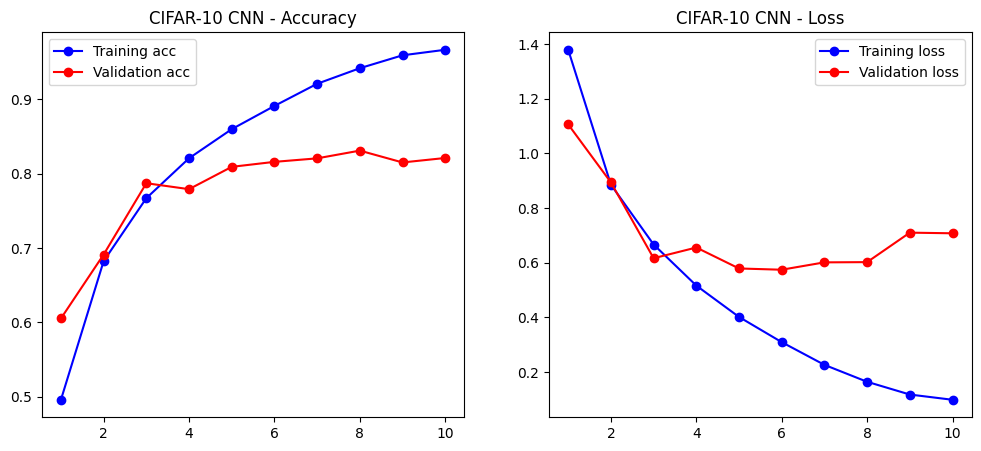

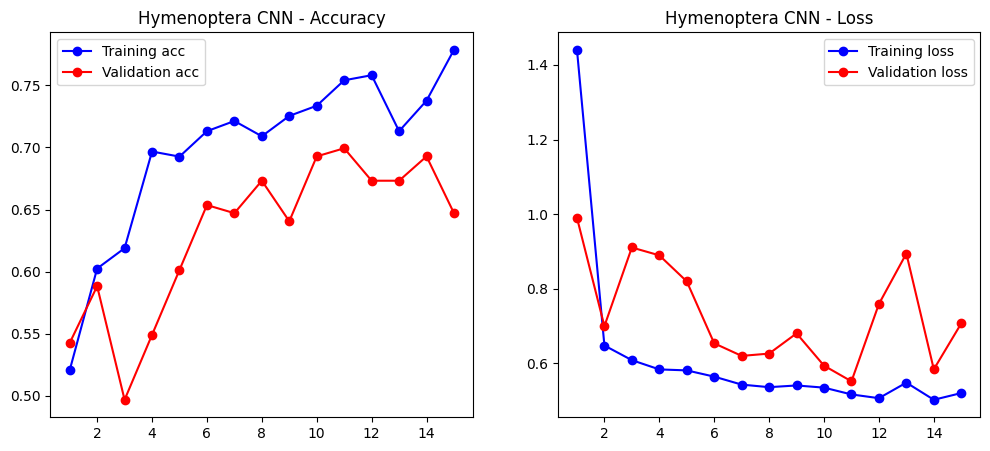

In [12]:
train.plot_history(history_cifar, title="CIFAR-10 CNN")
train.plot_history(history_hym, title="Hymenoptera CNN")

Calcul des prédictions pour Confusion Matrix - CNN sur CIFAR-10...


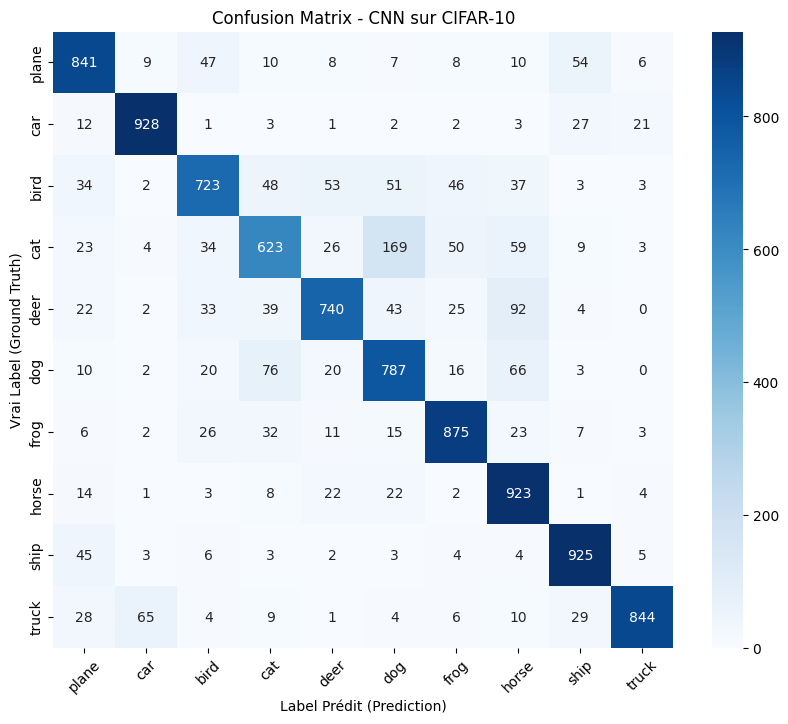

In [13]:
import Confusion_Matrix

# Noms des classes de CIFAR-10
cifar_classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Confusion_Matrix.compute_and_plot_cm(
    model=model_resnet_cifar,
    loader=val_loader_cifar, 
    class_names=cifar_classes, 
    device=device,
    title="Confusion Matrix - CNN sur CIFAR-10"
)

Calcul des prédictions pour Confusion Matrix - CNN sur Hymenoptera...


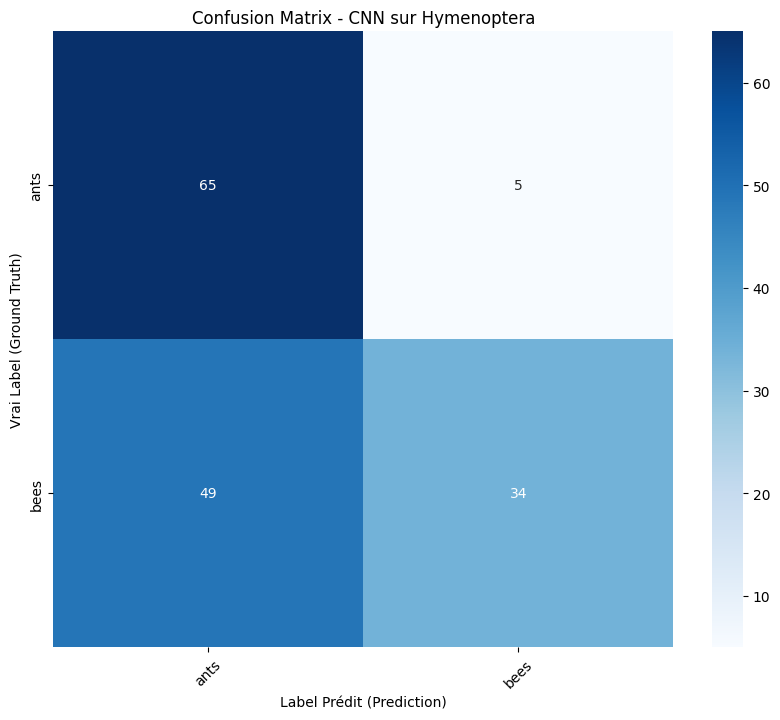

In [14]:
# Noms des classes de HYMENOPTERA
hym_classes = ['ants', 'bees'] 

Confusion_Matrix.compute_and_plot_cm(
    model=model_resnet_hym,
    loader=val_loader_hym, 
    class_names=hym_classes, 
    device=device,
    title="Confusion Matrix - CNN sur Hymenoptera"
)

# Modèle ViT

Maintenant nous allons entrainer un modèle ViT

# Compréhension du Vision Transformer (ViT)

Le ViT est une adaptation de l'architecture Transformer (initialement conçue pour le NLP) appliquée directement aux images. C'est une architecture **Encoder-Only**.



## 1ère partie : Préparation de la donnée (Patching)

Contrairement aux CNN qui traitent les pixels via des fenêtres glissantes, le ViT traite l'image comme une séquence de morceaux.

- **Découpage :** L'image $x \in \mathbb{R}^{H \times W \times C}$ est découpée en $N$ patches de taille fixe $(P, P)$.
- **Flattening :** Chaque patch 3D est aplati en un vecteur 1D.
    - Taille d'un vecteur patch : $P \times P \times C$.
    - *Exemple :* Pour des patchs $16 \times 16$ en couleur (RGB), la dimension est $16 \times 16 \times 3 = 768$.

## 2ème partie : Linear Projection (Patch Embeddings)

C'est ici qu'intervient une astuce souvent utilisée en implémentation mais peu détaillée en théorie.

- **Projection :** Chaque vecteur aplati passe dans une couche linéaire pour être projeté dans une dimension latente constante $D$ (ex: 768 pour ViT-Base).
- **Note d'implémentation (Conv2d) :** En pratique (dans PyTorch), au lieu d'aplatir puis de faire un Linear, on utilise souvent une couche **`nn.Conv2d`**.
    - *Kernel size* = Patch size
    - *Stride* = Patch size
    - Cela revient mathématiquement au même mais est plus optimisé computationnellement.

## 3ème partie : Le Token CLS (Class Token)

C'est une spécificité des architectures type BERT/ViT.

- Le modèle ajoute un vecteur **apprenable** au tout début de la séquence de patchs : $z_{0}^0 = x_{class}$.
- **Rôle :** Comme le mécanisme d'attention mélange l'information de tous les patchs, ce token "neutre" va servir d'éponge pour agréger l'information globale de l'image. C'est lui seul qui servira à la classification finale.

## 4ème partie : Positional Embeddings

Le Transformer ne connaît pas l'ordre des séquences (contrairement au RNN/CNN). Si on mélange les patchs, le modèle voit la même chose.

- **Injection de position :** On ajoute (somme élément par élément) un vecteur de position $E_{pos}$ à chaque embedding de patch.
- **Paramètres apprenables :** Dans le ViT standard, ces vecteurs de position sont des paramètres appris pendant l'entraînement (contrairement aux sinusoïdes fixes du Transformer original).
- **Formule d'entrée de l'encodeur :**
$$z_0 = [x_{class}; x_1^p E; x_2^p E; ...; x_N^p E] + E_{pos}$$

---

# Partie Boucle : Transformer Encoder Block

Le cœur du réseau est une répétition de $L$ blocs (ex: 12 pour ViT-Base).

## 5ème partie : Multi-Head Self Attention (MSA)

Contrairement au Transformer original, le ViT utilise une architecture **Pre-Norm** (Normalisation avant l'opération).

- **Layer Norm (LN) :** On normalise la matrice d'entrée $z_{l-1}$.
- **Attention ($Q, K, V$) :**
    - On projette l'entrée vers trois matrices : Query ($Q$), Key ($K$), Value ($V$).
    - On calcule l'attention (les poids d'importance entre chaque patch).
    - Formule de l'attention :
    $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
- **Connexion Résiduelle (Skip Connection) :** On ajoute l'entrée originale au résultat.
    - $z'_l = z_{l-1} + \text{MSA}(\text{LN}(z_{l-1}))$
- *Note :* La connexion résiduelle permet au gradient de circuler sans s'atténuer ("vanishing gradient") dans les réseaux profonds.

## 6ème partie : Feed Forward Network (MLP)

Après l'attention, l'information passe dans un petit réseau de neurones dense classique, appliqué à chaque vecteur de patch indépendamment mais de manière identique.

- **Architecture MLP :**
    1. Layer Norm (sur $z'_l$).
    2. Linear (Expansion) : Projette souvent vers une dimension $4 \times D$.
    3. **Activation GELU :** Le ViT utilise la *Gaussian Error Linear Unit* ($x \Phi(x)$) au lieu de ReLU. C'est une activation plus douce et probabiliste qui améliore souvent la convergence des Transformers.
    4. Linear (Projection) : Revient à la dimension $D$.
- **Connexion Résiduelle :**
    - Formule finale du bloc :
    $$z_l = z'_l + \text{MLP}(\text{LN}(z'_l))$$

---

# Sortie Finale (Classification Head)

À la sortie du dernier bloc $L$ :

- **Extraction :** On prend uniquement le premier vecteur de la séquence, correspondant au **Token CLS** ($z_L^0$).
- **Normalisation :** Une dernière Layer Norm est appliquée.
- **MLP Head :** Une couche linéaire projette ce vecteur vers le nombre de classes (Logits).
- **Softmax :** Conversion des logits en probabilités.
$$y = \text{Softmax}(\text{Linear}(\text{LN}(z_L^0)))$$

On déclare la classe ViT dans le fichier **Custom_ViT.py**

In [15]:
import Custom_ViT
import torch.optim as optim

print(f"Entraînement sur : {device}")

# --- Configuration "ViT-Tiny" ---
# On réduit la taille pour que ça apprenne plus vite sur nos petits datasets
VIT_CONFIG = {
    'img_size': 224,      # Standard ViT
    'patch_size': 16,     # Standard ViT
    'embed_dim': 384,     # Réduit (au lieu de 768)
    'depth': 6,           # Réduit (au lieu de 12)
    'n_heads': 6,         # Réduit (au lieu de 12)
    'mlp_ratio': 4.0,
    'dropout': 0.1
}

# 1. Modèle pour CIFAR-10 (10 Classes)
model_vit_cifar = Custom_ViT.ViT(
    **VIT_CONFIG,
    in_channels=3,
    n_classes=10
).to(device)

# 2. Modèle pour Hymenoptera (2 Classes)
model_vit_hym = Custom_ViT.ViT(
    **VIT_CONFIG,
    in_channels=3,
    n_classes=2
).to(device)

print("Modèles ViT initialisés.")

Entraînement sur : cuda
Modèles ViT initialisés.


In [16]:
# Fonction pour créer un DataLoader qui resize à la volée (plus économe en RAM)
class ResizedTensorDataset(torch.utils.data.Dataset):
    def __init__(self, x_tensor, y_tensor, target_size=(224, 224)):
        self.x = x_tensor
        self.y = y_tensor
        self.target_size = target_size

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx] # (3, 32, 32)
        label = self.y[idx]
        
        # Upscale bilinéaire à 224x224 juste avant d'envoyer au modèle
        img = F.interpolate(img.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False).squeeze(0)
        return img, label

# --- Création des Loaders CIFAR (Upscalés pour ViT) ---
# On utilise vos tenseurs x_train_cifar10 existants (qui sont en 32x32)
ds_train_vit_cifar = ResizedTensorDataset(x_train_cifar10, y_train_cifar10)
ds_val_vit_cifar   = ResizedTensorDataset(x_val_cifar10, y_val_cifar10)

loader_vit_cifar_train = DataLoader(ds_train_vit_cifar, batch_size=64, shuffle=True)
loader_vit_cifar_val   = DataLoader(ds_val_vit_cifar, batch_size=64, shuffle=False)

# --- Création des Loaders Hymenoptera (Déjà en 224x224) ---
# Pas besoin de la classe spéciale, ils sont déjà à la bonne taille
ds_train_hym = TensorDataset(x_train_hymenoptera, y_train_hymenoptera)
ds_val_hym   = TensorDataset(x_test_hymenoptera, y_test_hymenoptera) # Rappel : on a cloné val dans test

loader_vit_hym_train = DataLoader(ds_train_hym, batch_size=32, shuffle=True)
loader_vit_hym_val   = DataLoader(ds_val_hym, batch_size=32, shuffle=False)

print("DataLoaders ViT prêts (CIFAR upscalé à 224x224).")

DataLoaders ViT prêts (CIFAR upscalé à 224x224).


In [17]:
import torch.nn.functional as F
# --- Entraînement CIFAR-10 ---
print("\n=== ViT sur CIFAR-10 ===")

save_path = "vit_cifar10_weights.pth"
optimizer_vit_cifar = optim.AdamW(model_vit_cifar.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = torch.nn.CrossEntropyLoss()

# VÉRIFICATION DU FICHIER
if os.path.exists(save_path):
    print(f"--> Fichier de poids trouvé : '{save_path}'")
    print("--> Chargement du modèle... (Entraînement ignoré)")
    
    # Chargement des poids
    model_vit_cifar.load_state_dict(torch.load(save_path, map_location=device))
    
    # Création d'un historique vide pour ne pas faire planter les cellules de plot suivantes
    # (Note : Les courbes seront vides, mais le code continuera)
    history_vit_cifar = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [0.0]}
    
else:
    print("--> Aucun fichier de poids trouvé. Démarrage de l'entraînement...")
    
    history_vit_cifar = train.train_model(
        model=model_vit_cifar,
        train_loader=loader_vit_cifar_train,
        val_loader=loader_vit_cifar_val,
        criterion=criterion,
        optimizer=optimizer_vit_cifar,
        num_epochs=10, 
        device=device
    )
    
    # SAUVEGARDE
    torch.save(model_vit_cifar.state_dict(), save_path)
    print(f"Modèle sauvegardé sous : {save_path}")


=== ViT sur CIFAR-10 ===
--> Aucun fichier de poids trouvé. Démarrage de l'entraînement...
Démarrage de l'entraînement sur cuda pour 10 epochs
Epoch [1/10] Train Loss: 1.7011 Acc: 0.3706 | Val Loss: 1.4807 Acc: 0.4694
Epoch [2/10] Train Loss: 1.4096 Acc: 0.4883 | Val Loss: 1.3648 Acc: 0.5078
Epoch [3/10] Train Loss: 1.2758 Acc: 0.5376 | Val Loss: 1.2520 Acc: 0.5392
Epoch [4/10] Train Loss: 1.1626 Acc: 0.5802 | Val Loss: 1.1617 Acc: 0.5802
Epoch [5/10] Train Loss: 1.0854 Acc: 0.6069 | Val Loss: 1.1402 Acc: 0.5836
Epoch [6/10] Train Loss: 1.0187 Acc: 0.6316 | Val Loss: 1.1379 Acc: 0.5924
Epoch [7/10] Train Loss: 0.9593 Acc: 0.6545 | Val Loss: 1.0477 Acc: 0.6218
Epoch [8/10] Train Loss: 0.9035 Acc: 0.6758 | Val Loss: 0.9593 Acc: 0.6558
Epoch [9/10] Train Loss: 0.8503 Acc: 0.6947 | Val Loss: 1.0634 Acc: 0.6266
Epoch [10/10] Train Loss: 0.8063 Acc: 0.7110 | Val Loss: 0.9602 Acc: 0.6596
Entraînement terminé en 36m 33s
Modèle sauvegardé sous : vit_cifar10_weights.pth


In [18]:
# --- Entraînement Hymenoptera ---
print("\n=== ViT sur Hymenoptera ===")

save_path = "vit_Hymenoptera_weights.pth"
optimizer_vit_hym = optim.AdamW(model_vit_hym.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = torch.nn.CrossEntropyLoss()

# VÉRIFICATION DU FICHIER
if os.path.exists(save_path):
    print(f"--> Fichier de poids trouvé : '{save_path}'")
    print("--> Chargement du modèle... (Entraînement ignoré)")
    
    # Chargement des poids
    model_vit_hym.load_state_dict(torch.load(save_path, map_location=device))
    
    # Création d'un historique vide pour ne pas faire planter les cellules de plot suivantes
    # (Note : Les courbes seront vides, mais le code continuera)
    history_vit_hym = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [0.0]}
    
else:
    print("--> Aucun fichier de poids trouvé. Démarrage de l'entraînement...")
    
    history_vit_hym = train.train_model(
        model=model_vit_hym,
        train_loader=loader_vit_hym_train,
        val_loader=loader_vit_hym_val,
        criterion=criterion,
        optimizer=optimizer_vit_hym,
        num_epochs=10, 
        device=device
    )
    
    # SAUVEGARDE
    torch.save(model_vit_hym.state_dict(), save_path)
    print(f"Modèle sauvegardé sous : {save_path}")


=== ViT sur Hymenoptera ===
--> Aucun fichier de poids trouvé. Démarrage de l'entraînement...
Démarrage de l'entraînement sur cuda pour 10 epochs
Epoch [1/10] Train Loss: 1.0634 Acc: 0.5205 | Val Loss: 0.7188 Acc: 0.5425
Epoch [2/10] Train Loss: 0.7622 Acc: 0.4549 | Val Loss: 0.7452 Acc: 0.4575
Epoch [3/10] Train Loss: 0.7034 Acc: 0.5123 | Val Loss: 0.7024 Acc: 0.5425
Epoch [4/10] Train Loss: 0.6951 Acc: 0.5328 | Val Loss: 0.7127 Acc: 0.4575
Epoch [5/10] Train Loss: 0.6909 Acc: 0.5287 | Val Loss: 0.6914 Acc: 0.4902
Epoch [6/10] Train Loss: 0.6783 Acc: 0.6025 | Val Loss: 0.6860 Acc: 0.5817
Epoch [7/10] Train Loss: 0.6736 Acc: 0.6230 | Val Loss: 0.6916 Acc: 0.4837
Epoch [8/10] Train Loss: 0.6760 Acc: 0.5697 | Val Loss: 0.6885 Acc: 0.5359
Epoch [9/10] Train Loss: 0.6560 Acc: 0.6189 | Val Loss: 0.6815 Acc: 0.5556
Epoch [10/10] Train Loss: 0.6354 Acc: 0.6475 | Val Loss: 0.6953 Acc: 0.5425
Entraînement terminé en 0m 12s
Modèle sauvegardé sous : vit_Hymenoptera_weights.pth


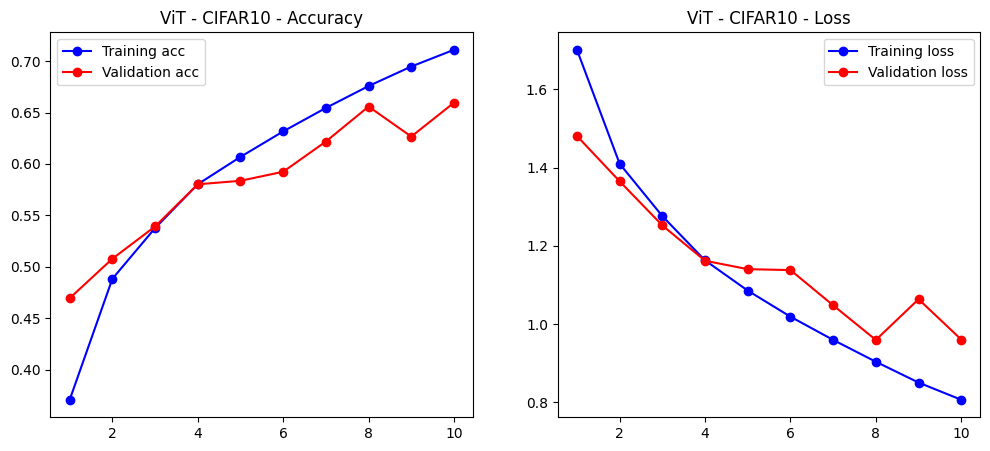

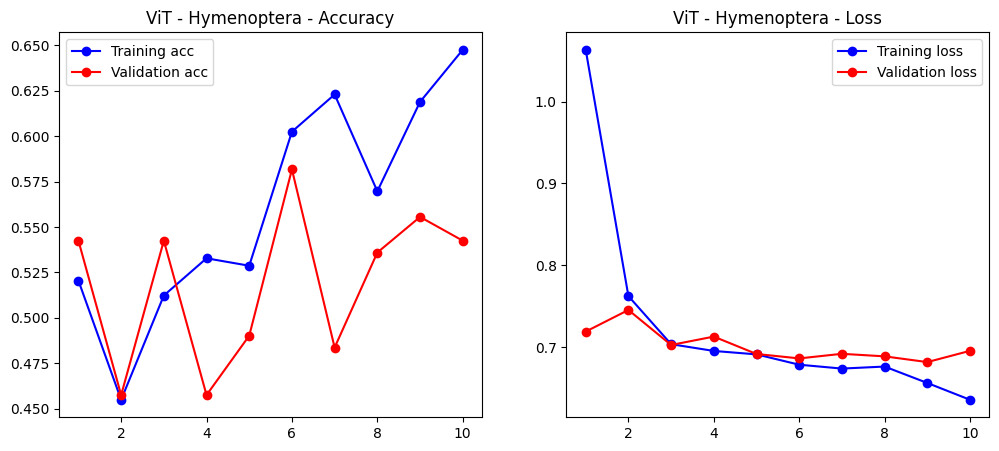

In [19]:
train.plot_history(history_vit_cifar, title="ViT - CIFAR10")
train.plot_history(history_vit_hym, title="ViT - Hymenoptera")

Calcul des prédictions pour ViT Confusion - CIFAR...


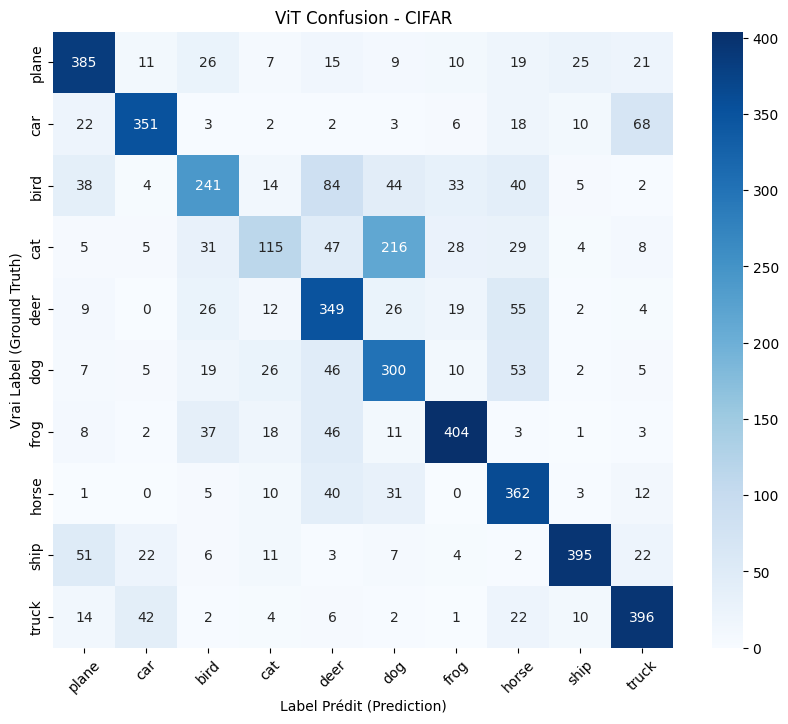

Calcul des prédictions pour ViT Confusion - Hymenoptera...


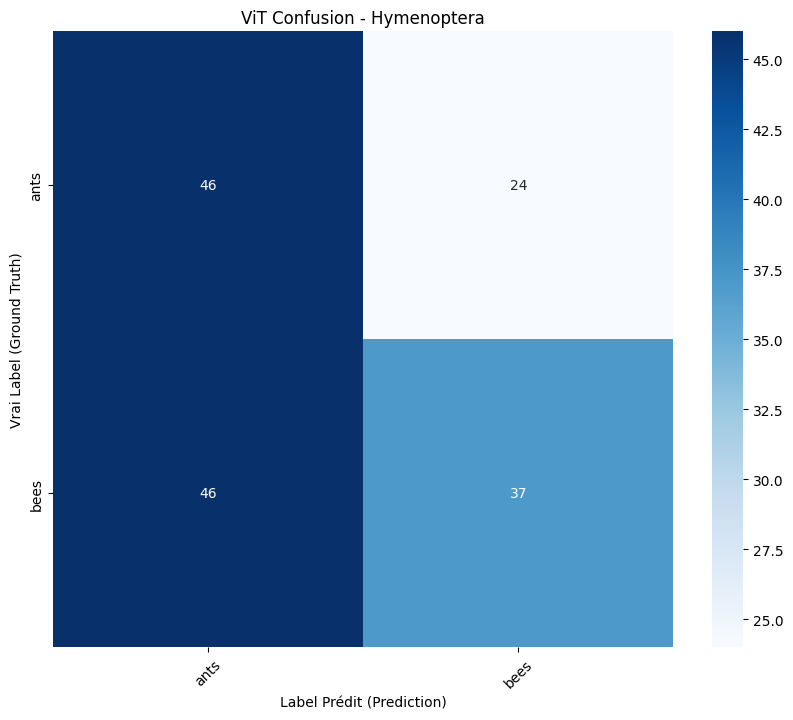

In [20]:
Confusion_Matrix.compute_and_plot_cm(model_vit_cifar, loader_vit_cifar_val, cifar_classes, device, title="ViT Confusion - CIFAR")
Confusion_Matrix.compute_and_plot_cm(model_vit_hym, loader_vit_hym_val, hym_classes, device, title="ViT Confusion - Hymenoptera")

# Comparaison des modèles

In [22]:
import Compare

# 1. Récupération sécurisée des accuracies
# (On met 0.0 par défaut si l'historique n'est pas trouvé dans les variables)
def get_acc(var_name, local_vars):
    if var_name in local_vars:
        # On prend la dernière valeur de validation (val_acc)
        return local_vars[var_name]['val_acc'][-1]
    return 0.0

# 2. Récupération avec les BONS noms de variables (tels qu'utilisés lors du training)
# CNN / ResNet
acc_resnet_cifar = get_acc('history_cifar', locals())
acc_resnet_hym   = get_acc('history_hym', locals())

# ViT
acc_vit_cifar    = get_acc('history_vit_cifar', locals())
acc_vit_hym      = get_acc('history_vit_hym', locals())


print(f"Accuracies récupérées :")
print(f"CNN Cifar: {acc_resnet_cifar:.2%}")
print(f"CNN Hym  : {acc_resnet_hym:.2%}")
print(f"ViT Cifar: {acc_vit_cifar:.2%}")
print(f"ViT Hym  : {acc_vit_hym:.2%})")

# 2. Dictionnaire des Modèles à comparer
models_dict = {
    'ResNet_CIFAR10': model_resnet_cifar,
    'ResNet_Hymenoptera': model_resnet_hym,
    'ViT_CIFAR10': model_vit_cifar,
    'ViT_Hymenoptera': model_vit_hym
}

# 3. Input Shapes (Crucial pour le calcul des FLOPs)
input_shapes_dict = {
    # Le ResNet/CNN prend l'image native
    'ResNet_CIFAR10': (1, 3, 32, 32),
    'ResNet_Hymenoptera': (1, 3, 224, 224),
    
    # Le ViT a besoin de 224x224 (via upscaling pour CIFAR)
    'ViT_CIFAR10': (1, 3, 224, 224),
    'ViT_Hymenoptera': (1, 3, 224, 224)
}

# 4. Accuracies
accuracies_dict = {
    'ResNet_CIFAR10': acc_resnet_cifar,
    'ResNet_Hymenoptera': acc_resnet_hym,
    'ViT_CIFAR10': acc_vit_cifar,
    'ViT_Hymenoptera': acc_vit_hym
}

# 5. Temps (A remplir si tu les as, sinon 0)
train_times_dict = {
    'ResNet_CIFAR10': 3*60+56.1, 'ResNet_Hymenoptera': 60+50.1,
    'ViT_CIFAR10': 34*60+47, 'ViT_Hymenoptera': 20.1
}

test_times_dict = {
    'ResNet_CIFAR10': 0, 'ResNet_Hymenoptera': 0,
    'ViT_CIFAR10': 0, 'ViT_Hymenoptera': 0
}

results = Compare.compare_models(
    models_dict=models_dict,
    input_shapes_dict=input_shapes_dict,
    accuracies_dict=accuracies_dict,
    train_times_dict=train_times_dict,
    test_times_dict=test_times_dict,
    device=device
)

Accuracies récupérées :
CNN Cifar: 82.09%
CNN Hym  : 64.71%
ViT Cifar: 65.96%
ViT Hym  : 54.25%)
COMPARAISON DES MODÈLES

Analyse de ResNet_CIFAR10...
  Input shape: (1, 3, 32, 32)
  ✓ Test Accuracy: 82.09%
  ✓ FLOPs: 1.12 GFLOPs
  ✓ Paramètres: 11.17 M
  ✓ Mémoire (inférence): 722.99 MB
  ✓ Mémoire (entraînement): 716.97 MB
  ✓ Temps d'entraînement: 236.10s
  ✓ Temps de test: 0.00s

Analyse de ResNet_Hymenoptera...
  Input shape: (1, 3, 224, 224)
  ✓ Test Accuracy: 64.71%
  ✓ FLOPs: 54.67 GFLOPs
  ✓ Paramètres: 11.17 M
  ✓ Mémoire (inférence): 774.98 MB
  ✓ Mémoire (entraînement): 925.92 MB
  ✓ Temps d'entraînement: 110.10s
  ✓ Temps de test: 0.00s

Analyse de ViT_CIFAR10...
  Input shape: (1, 3, 224, 224)
  ✓ Test Accuracy: 65.96%
  ✓ FLOPs: 2.91 GFLOPs
  ✓ Paramètres: 7.40 M
  ✓ Mémoire (inférence): 717.18 MB
  ✓ Mémoire (entraînement): 716.70 MB
  ✓ Temps d'entraînement: 2087.00s
  ✓ Temps de test: 0.00s

Analyse de ViT_Hymenoptera...
  Input shape: (1, 3, 224, 224)
  ✓ Test Accura

## Interprétabilité ViT

--- Analyse ViT CIFAR-10 ---
Vraie classe : horse


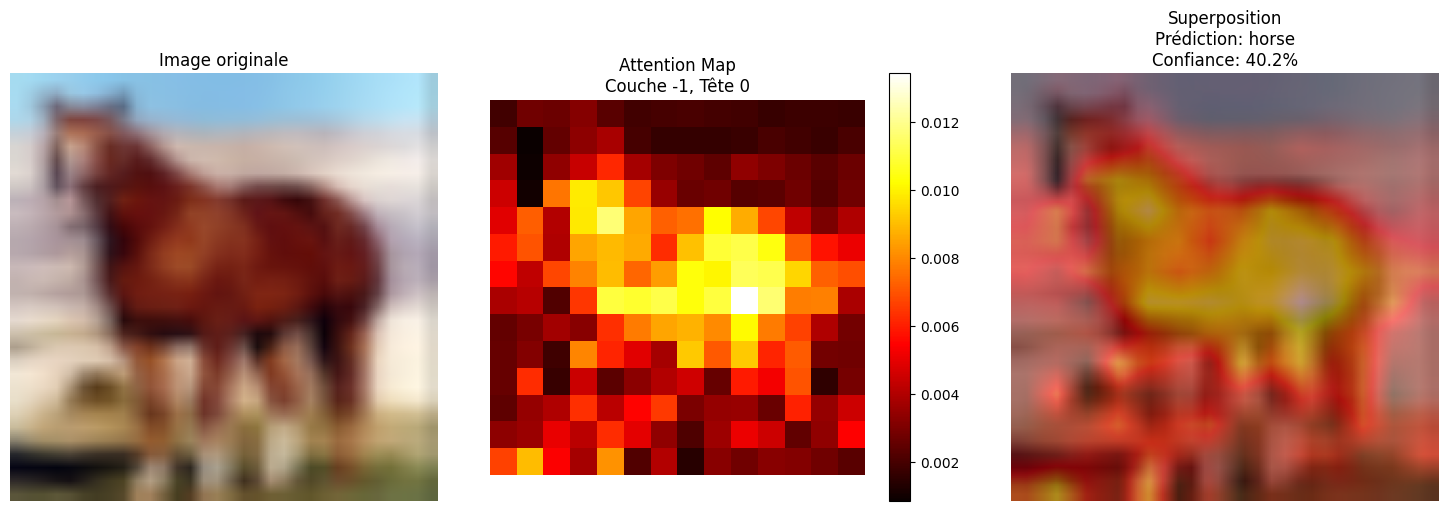

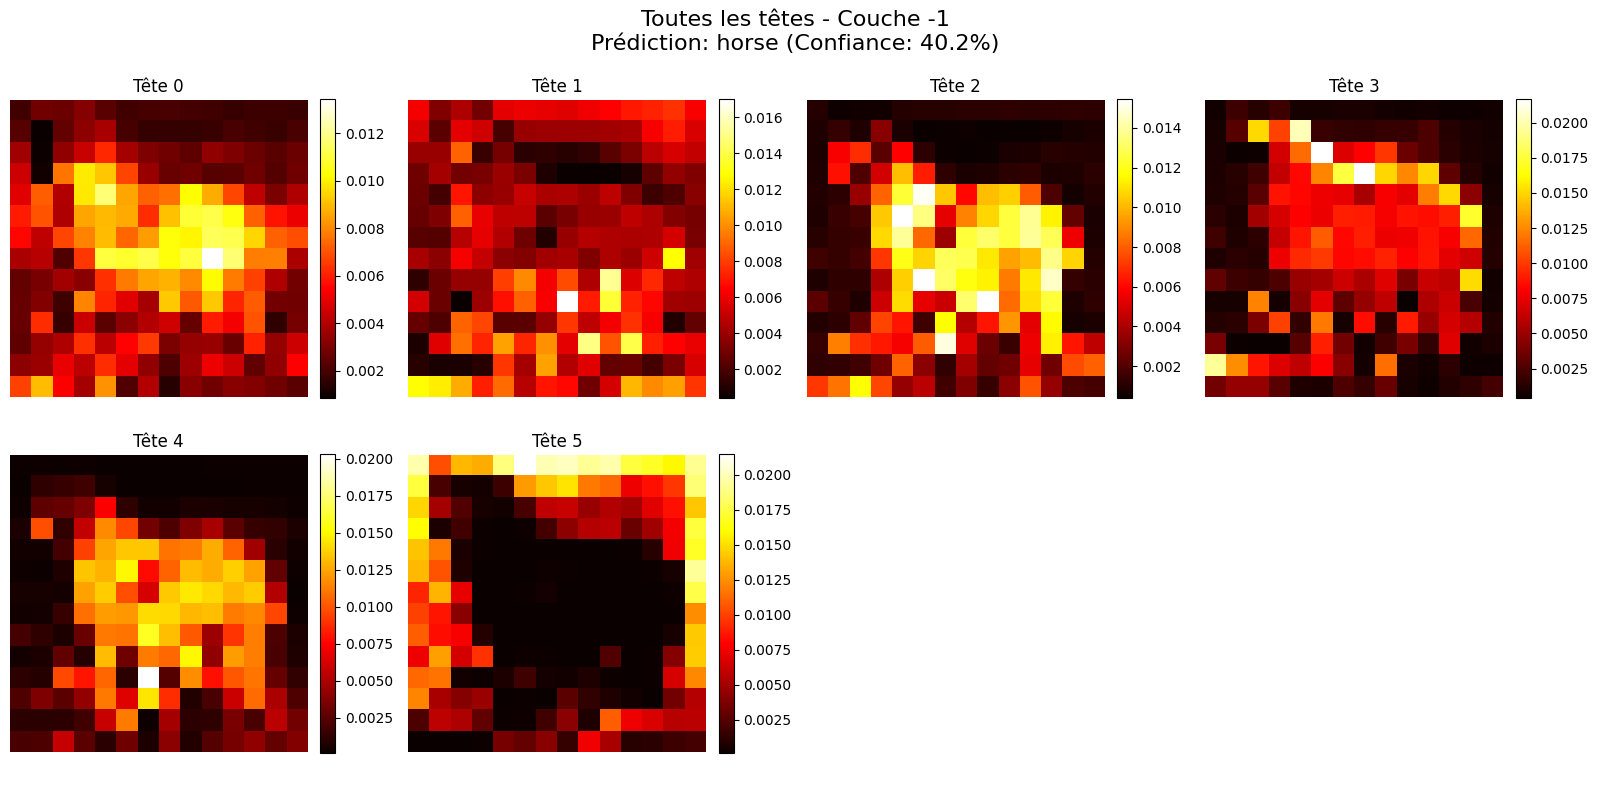

In [31]:
import interpretabilite
import random

# 1. Instanciation de l'interpréteur
interpreter_cifar = interpretabilite.ViTInterpreter(model_vit_cifar, device)

# 2. Récupération d'une image de test CIFAR
# On prend le loader de validation défini précédemment
images, labels = next(iter(loader_vit_cifar_val))
idx = random.randint(0, images.size(0) - 1)
image = images[idx]
label = labels[idx].item()
true_class_name = cifar_classes[label]

print(f"--- Analyse ViT CIFAR-10 ---")
print(f"Vraie classe : {true_class_name}")

# 3. Visualisation d'une tête spécifique (ex: Dernière couche, Tête 0)
# Cela montre où le modèle regarde "le plus" juste avant de décider
_ = interpreter_cifar.visualize_attention(
    image, 
    class_names=cifar_classes, 
    layer_idx=-1,  # Dernière couche
    head_idx=0     # Première tête d'attention
)

# 4. Visualisation de TOUTES les têtes de la dernière couche
# Permet de voir la diversité : certaines têtes regardent la forme, d'autres le fond, etc.
interpreter_cifar.visualize_all_heads(
    image, 
    class_names=cifar_classes, 
    layer_idx=-1
)